In [195]:
import pandas as pd
import numpy as np
import sys
import os

from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from scipy.stats import boxcox

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling2D, LSTM, BatchNormalization, GRU, Attention, GlobalAveragePooling1D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dropout

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정|

### 데이터 불러오기

In [196]:
# 1-1. 사용자 설정 경로 및 변수
GANGNAM_DIRECTORY = '../../data/raw/'
IMAGE_DIRECTORY = '../../data/interim/satellites/gang_nam_rot_90'

TABULAR_DATA_PATH = '../../data/interim/gang_nam_sendimental_score_with_sale.csv'

IMAGE_EXTENSION = '.jpg' # 이미지 파일 확장자 (.png, .jpeg 등)
DATE_COLUMN = '계약일자'
TARGET_COLUMN = '면적당 단가(만원)' # 예측할 실제 타겟 컬럼명

# 1-2. 모델 파라미터
LOOKBACK = 10      # 과거 10개의 거래 데이터를 보고 다음 거래를 예측
BATCH_SIZE = 64
EPOCHS = 100

standard_scaler = StandardScaler()

In [197]:
# 2-1. CSV 파일 로드 및 날짜 기준 정렬
#print("1. 데이터를 로드하고 정렬합니다...")
df = pd.read_csv(TABULAR_DATA_PATH)
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df = df.sort_values(DATE_COLUMN).reset_index(drop=True)
df.drop(columns=['sentiment_score'], axis=1, inplace=True)
df['date'] = df['계약일자'].dt.strftime('%Y-%m')
df.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate,date
0,84.73,5,1994,7.399156,24,2018-07-01,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5,2018-07


In [198]:
df.describe()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
count,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561,21561.000000,2.156100e+04,21561.000000,21561.000000,21561.000000,21561.000000,21561.00000,21561.000000,21561.000000,21561.000000
mean,89.029772,9.551691,1998.917304,7.705838,22.522749,2021-12-10 19:21:45.857798912,105.902365,1.253241e+07,117.314447,119.287570,0.470288,2.714529,99.56682,384.413571,33.939103,1.957029
min,12.100000,-1.000000,1974.000000,5.689222,-1.000000,2018-07-01 00:00:00,94.600000,9.346282e+06,74.300000,72.900000,0.021000,0.054000,86.60000,37.000000,3.000000,0.500000
25%,59.884800,4.000000,1988.000000,7.462485,13.000000,2019-11-09 00:00:00,97.400000,1.114621e+07,109.800000,111.100000,0.406000,1.301000,95.30000,246.000000,22.000000,1.000000
50%,84.670000,8.000000,2001.000000,7.750563,21.000000,2021-05-02 00:00:00,106.500000,1.244454e+07,119.400000,121.100000,0.477000,2.551000,100.30000,331.000000,29.000000,1.500000
75%,110.820000,13.000000,2007.000000,7.988213,32.000000,2024-05-02 00:00:00,115.200000,1.376311e+07,127.500000,130.000000,0.566000,3.775000,103.90000,524.000000,46.000000,3.250000
max,301.470000,68.000000,2024.000000,9.083827,50.000000,2025-06-30 00:00:00,119.600000,1.789257e+07,139.400000,143.300000,0.777000,6.423000,110.00000,906.000000,80.000000,3.500000
std,42.223486,7.619940,12.304202,0.402817,12.315347,NaN,8.573957,1.724363e+06,12.222551,13.208922,0.144929,1.622203,5.27094,199.452068,18.064948,1.139994


In [199]:
# 2-2. 이미지 전체 경로 생성
df['image_filename'] = [f'apt_image_{i}{IMAGE_EXTENSION}' for i in df.index]
df['image_path'] = df['image_filename'].apply(lambda filename: os.path.join(IMAGE_DIRECTORY, filename))

print("=========================")
print("최종 전처리 완료된 데이터 입니다.")
print("=========================\n")
df.info()

최종 전처리 완료된 데이터 입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21561 entries, 0 to 21560
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   전용면적(㎡)         21561 non-null  float64       
 1   층               21561 non-null  int64         
 2   건축년도            21561 non-null  int64         
 3   면적당 단가(만원)      21561 non-null  float64       
 4   아파트 나이          21561 non-null  int64         
 5   계약일자            21561 non-null  datetime64[ns]
 6   leading_index   21561 non-null  float64       
 7   건설기성액(백만원)      21561 non-null  float64       
 8   부동산_소비심리지수      21561 non-null  float64       
 9   주택시장_소비심리지수     21561 non-null  float64       
 10  강남구_변동률         21561 non-null  float64       
 11  강남구_누계          21561 non-null  float64       
 12  토지시장_소비심리지수     21561 non-null  float64       
 13  아파트_호수          21561 non-null  float64       
 14  아파트_면적          21561 non-null  f

In [200]:

# 원본 데이터 복사
df_boxcox_qt = df.copy()


# -----------------------------------------------------
# ❗️ 2. 변환 적용
# -----------------------------------------------------
# 숫자형 컬럼만 선택
numeric_cols = df.select_dtypes(include=np.number).columns
print(f"수치형 컬럼 : ", numeric_cols)


수치형 컬럼 :  Index(['전용면적(㎡)', '층', '건축년도', '면적당 단가(만원)', '아파트 나이', 'leading_index',
       '건설기성액(백만원)', '부동산_소비심리지수', '주택시장_소비심리지수', '강남구_변동률', '강남구_누계',
       '토지시장_소비심리지수', '아파트_호수', '아파트_면적', 'rate'],
      dtype='object')


In [201]:

# (1) 양수만 있는 컬럼 찾기
# 알맞은거로 자동 찾음
boxcox_cols = ['건축년도','건설기성액(백만원)','부동산_소비심리지수',
               'leading_index','토지시장_소비심리지수', 'rate']

# (2) 음수 또는 0이 포함된 컬럼 찾기
# 강제로 변환
quantile_cols = ['전용면적(㎡)', '면적당 단가(만원)', '층',
                '주택시장_소비심리지수', '아파트_면적', '아파트 나이',
                '강남구_변동률', '강남구_누계', '아파트_호수']

print("✅ 분위수 변환 대상 컬럼 (음수/0 포함):", quantile_cols)
print("✅ Box-Cox 변환 대상 컬럼 (양수만):", boxcox_cols)

# (3) 변환기(Transformer)를 사용하여 데이터 변환
# Quantile Transformer 적용
if quantile_cols:
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
    df_boxcox_qt[quantile_cols] = qt.fit_transform(df[quantile_cols])

# Box-Cox Transformer 적용
if boxcox_cols:
    pt = PowerTransformer(method='box-cox')
    df_boxcox_qt[boxcox_cols] = pt.fit_transform(df[boxcox_cols])

#df_boxcox_qt[numeric_cols] = standard_scaler.fit_transform(df_boxcox_qt[numeric_cols])


✅ 분위수 변환 대상 컬럼 (음수/0 포함): ['전용면적(㎡)', '면적당 단가(만원)', '층', '주택시장_소비심리지수', '아파트_면적', '아파트 나이', '강남구_변동률', '강남구_누계', '아파트_호수']
✅ Box-Cox 변환 대상 컬럼 (양수만): ['건축년도', '건설기성액(백만원)', '부동산_소비심리지수', 'leading_index', '토지시장_소비심리지수', 'rate']


### 시각화

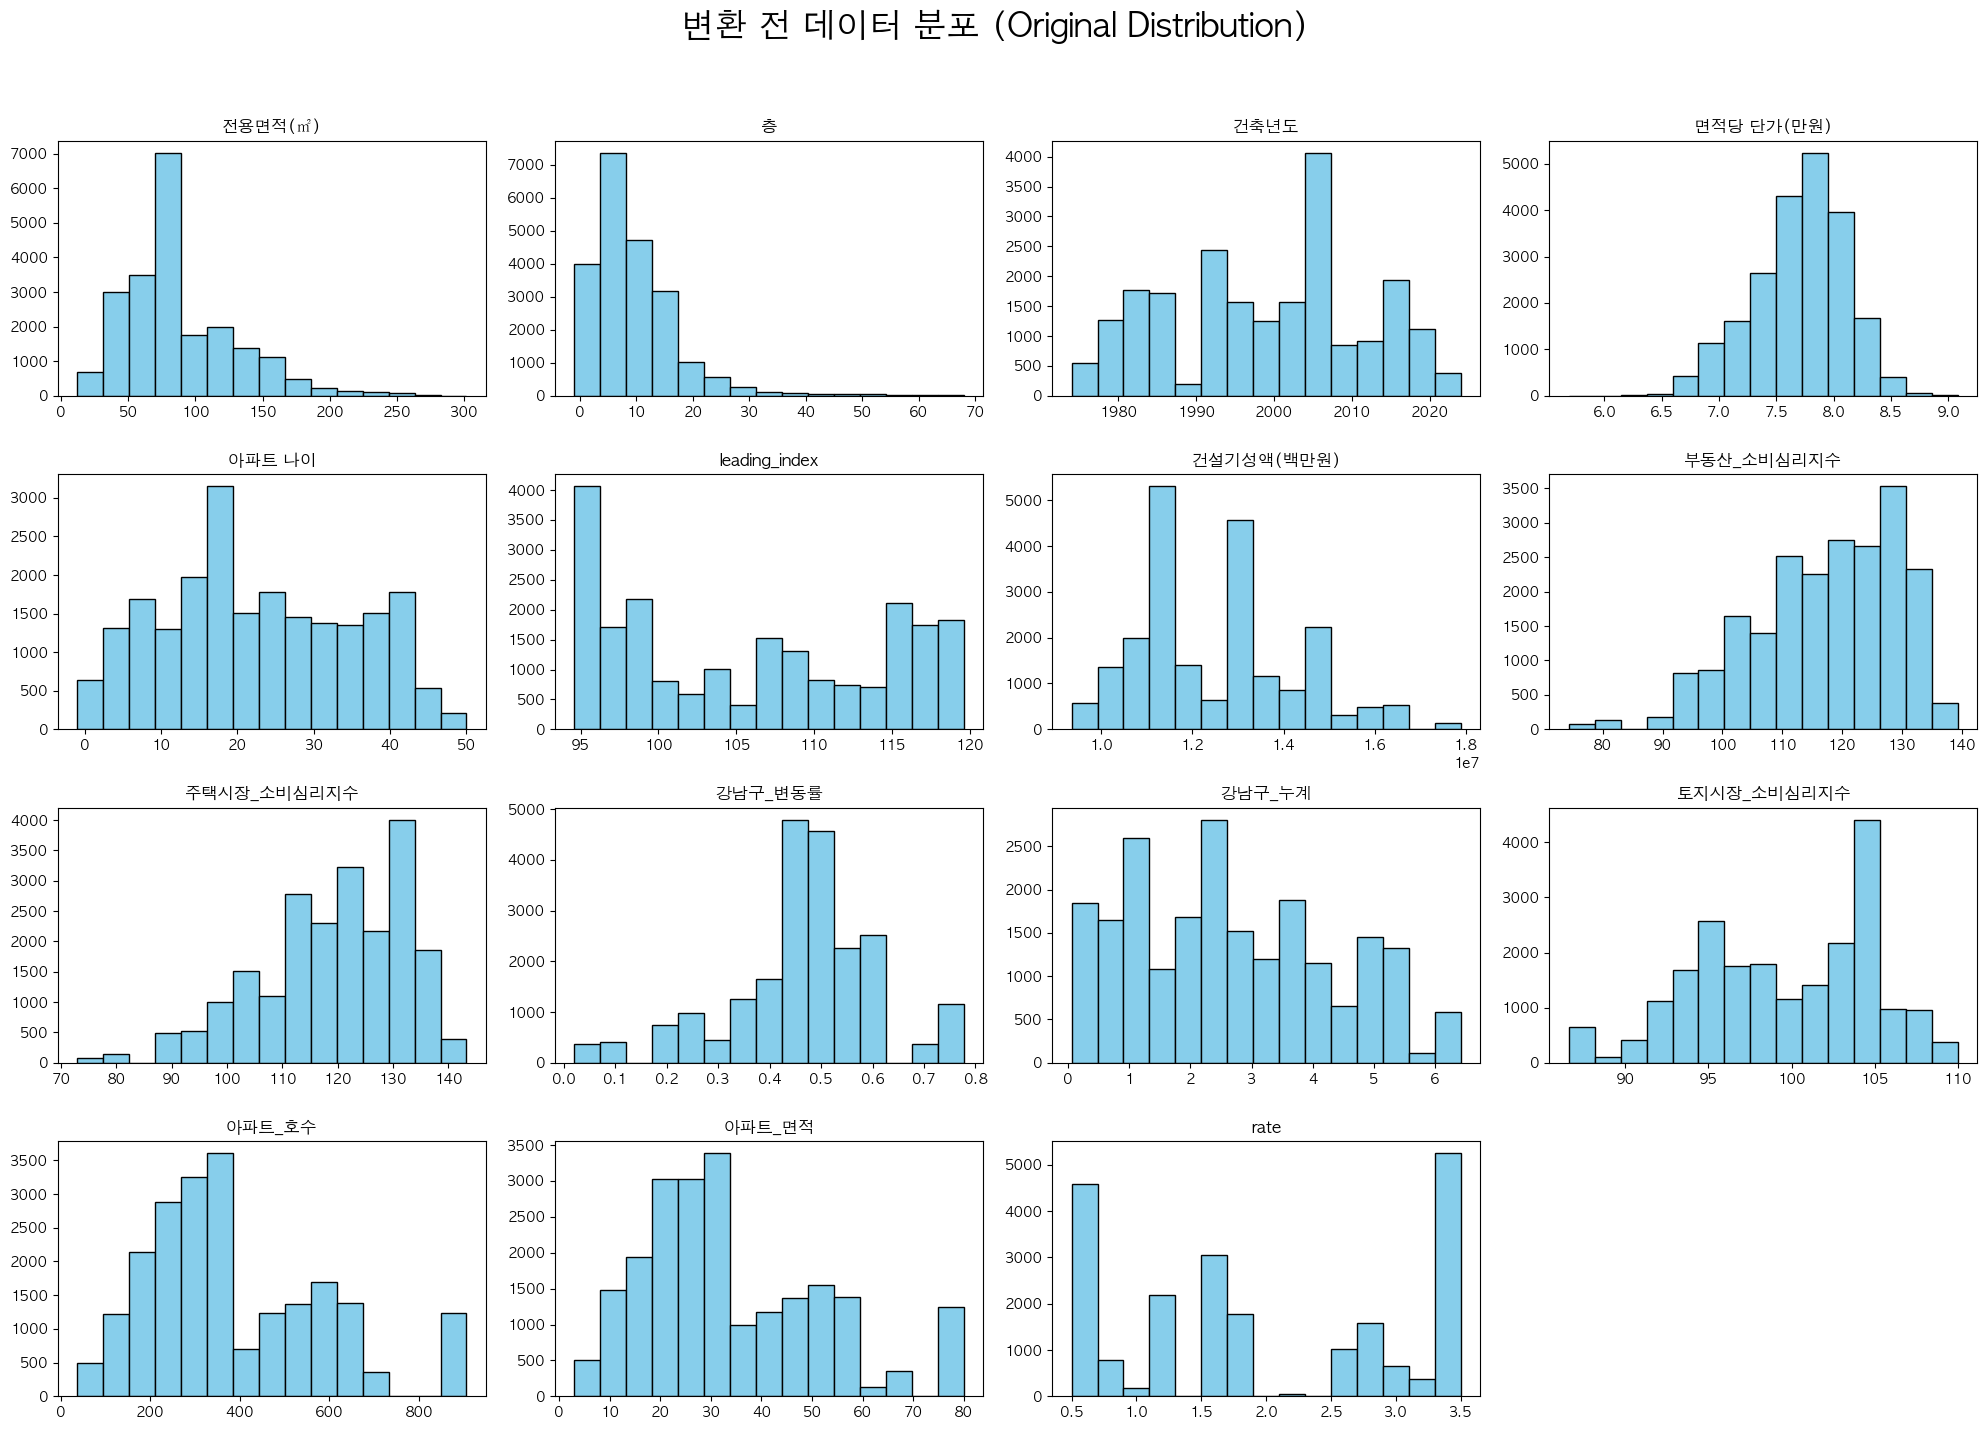

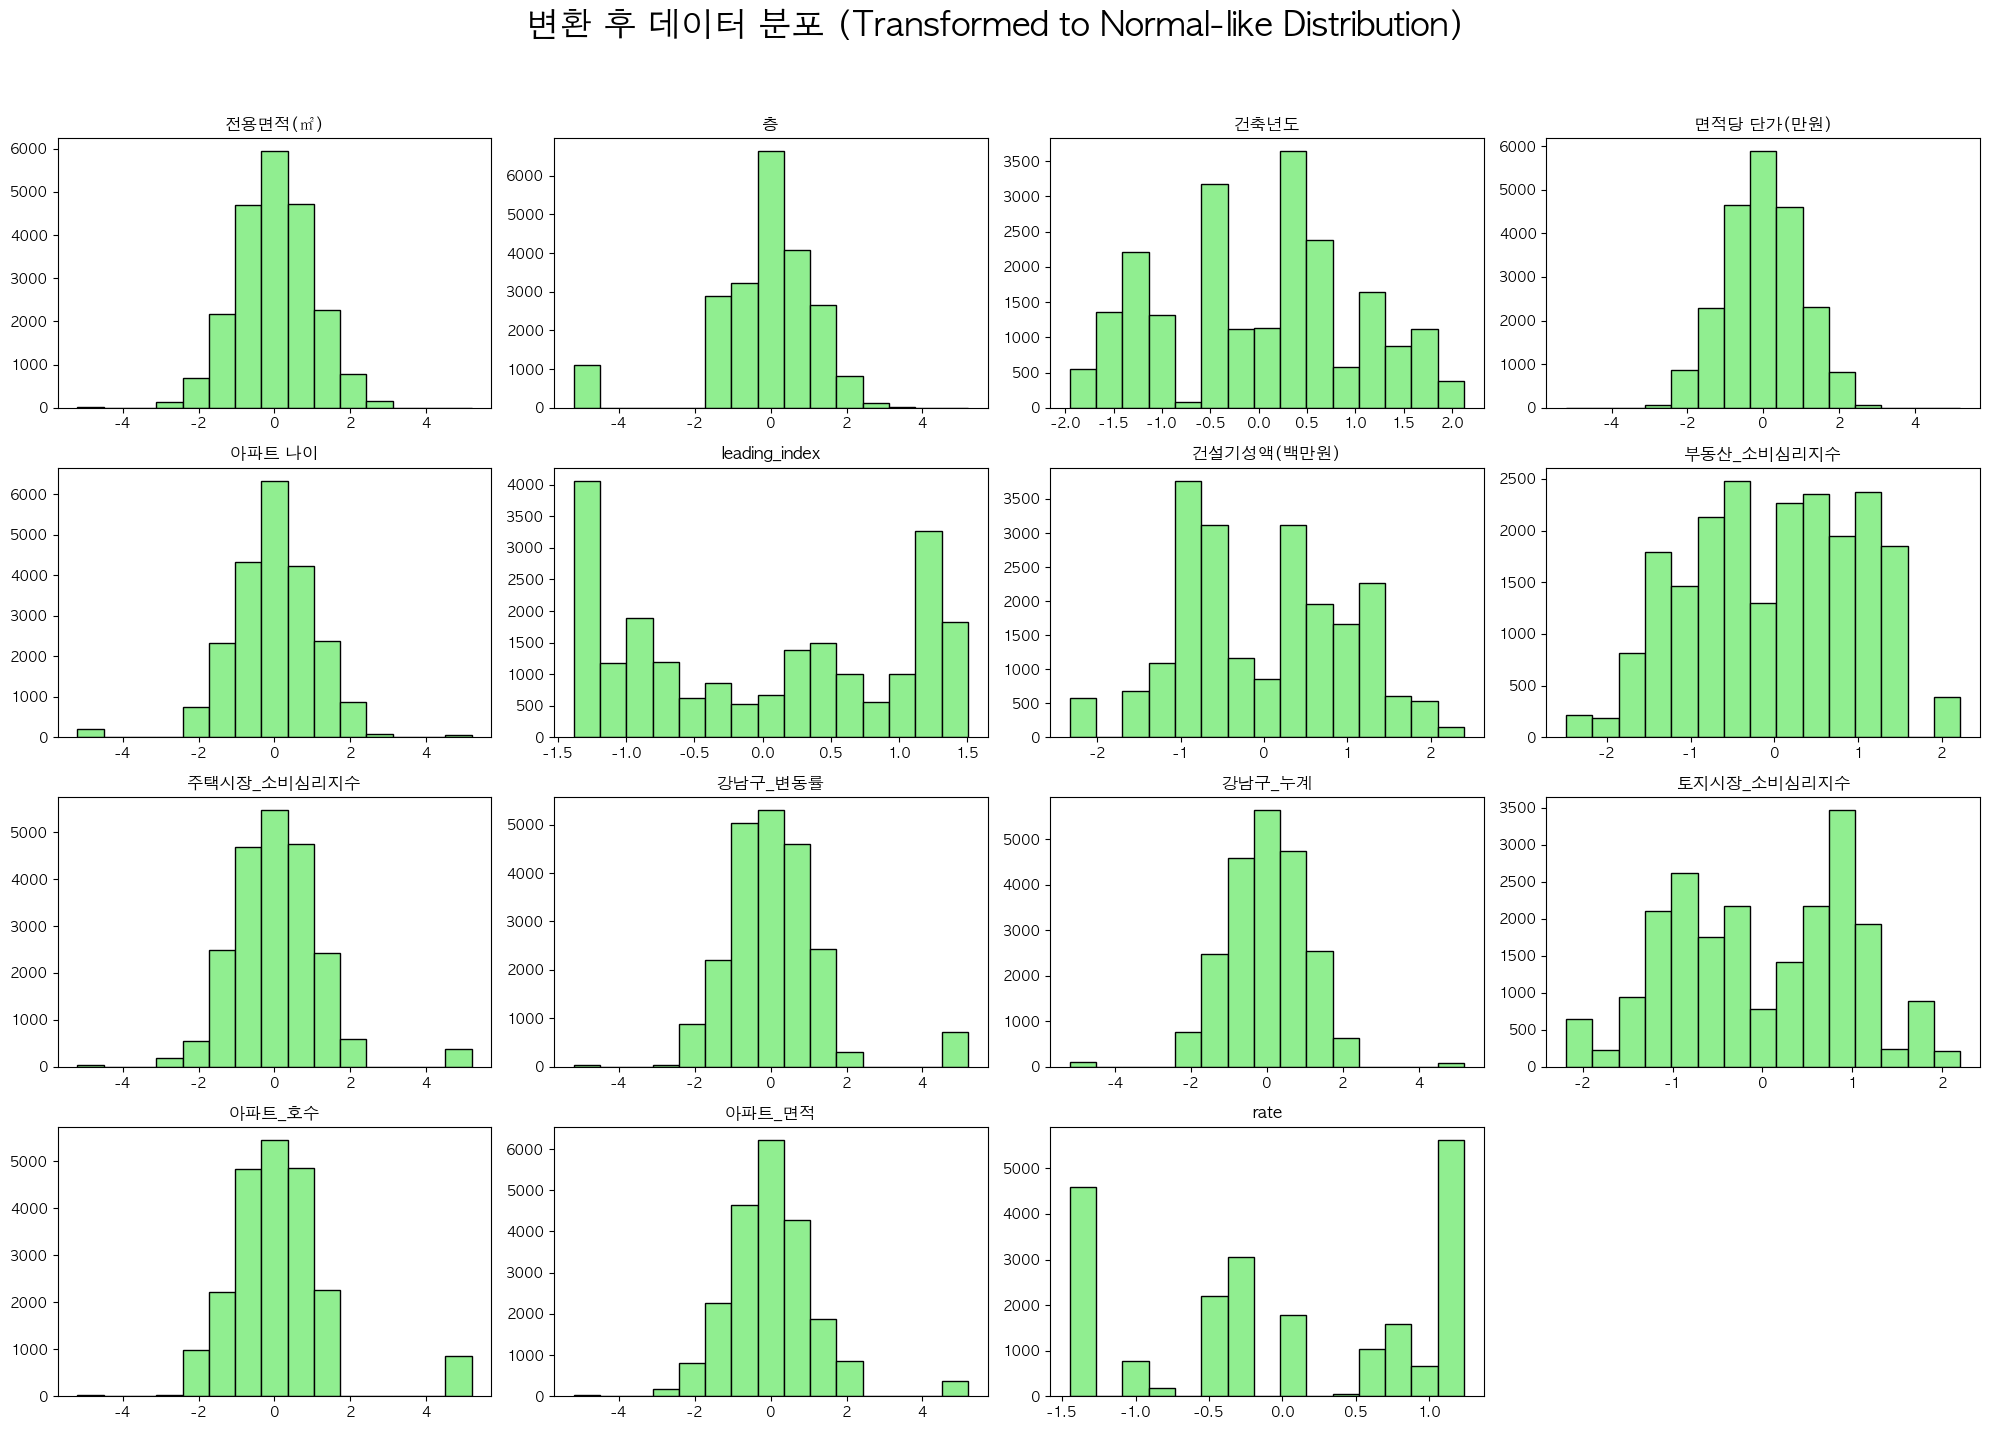

In [202]:

# -----------------------------------------------------
# ❗️ 3. 시각화
# -----------------------------------------------------
# 변환 전 데이터 분포
axes_before = df[numeric_cols].hist(figsize=(20, 15), bins=15, color='skyblue', edgecolor='black')
plt.suptitle("변환 전 데이터 분포 (Original Distribution)", fontsize=24)
for ax in axes_before.ravel():
    ax.grid(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 제목과 겹치지 않게 조정
plt.show()

# 변환 후 데이터 분포
axes_after = df_boxcox_qt[numeric_cols].hist(figsize=(20, 15), bins=15, color='lightgreen', edgecolor='black')
plt.suptitle("변환 후 데이터 분포 (Transformed to Normal-like Distribution)", fontsize=24)
for ax in axes_after.ravel():
    ax.grid(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 제목과 겹치지 않게 조정
plt.show()

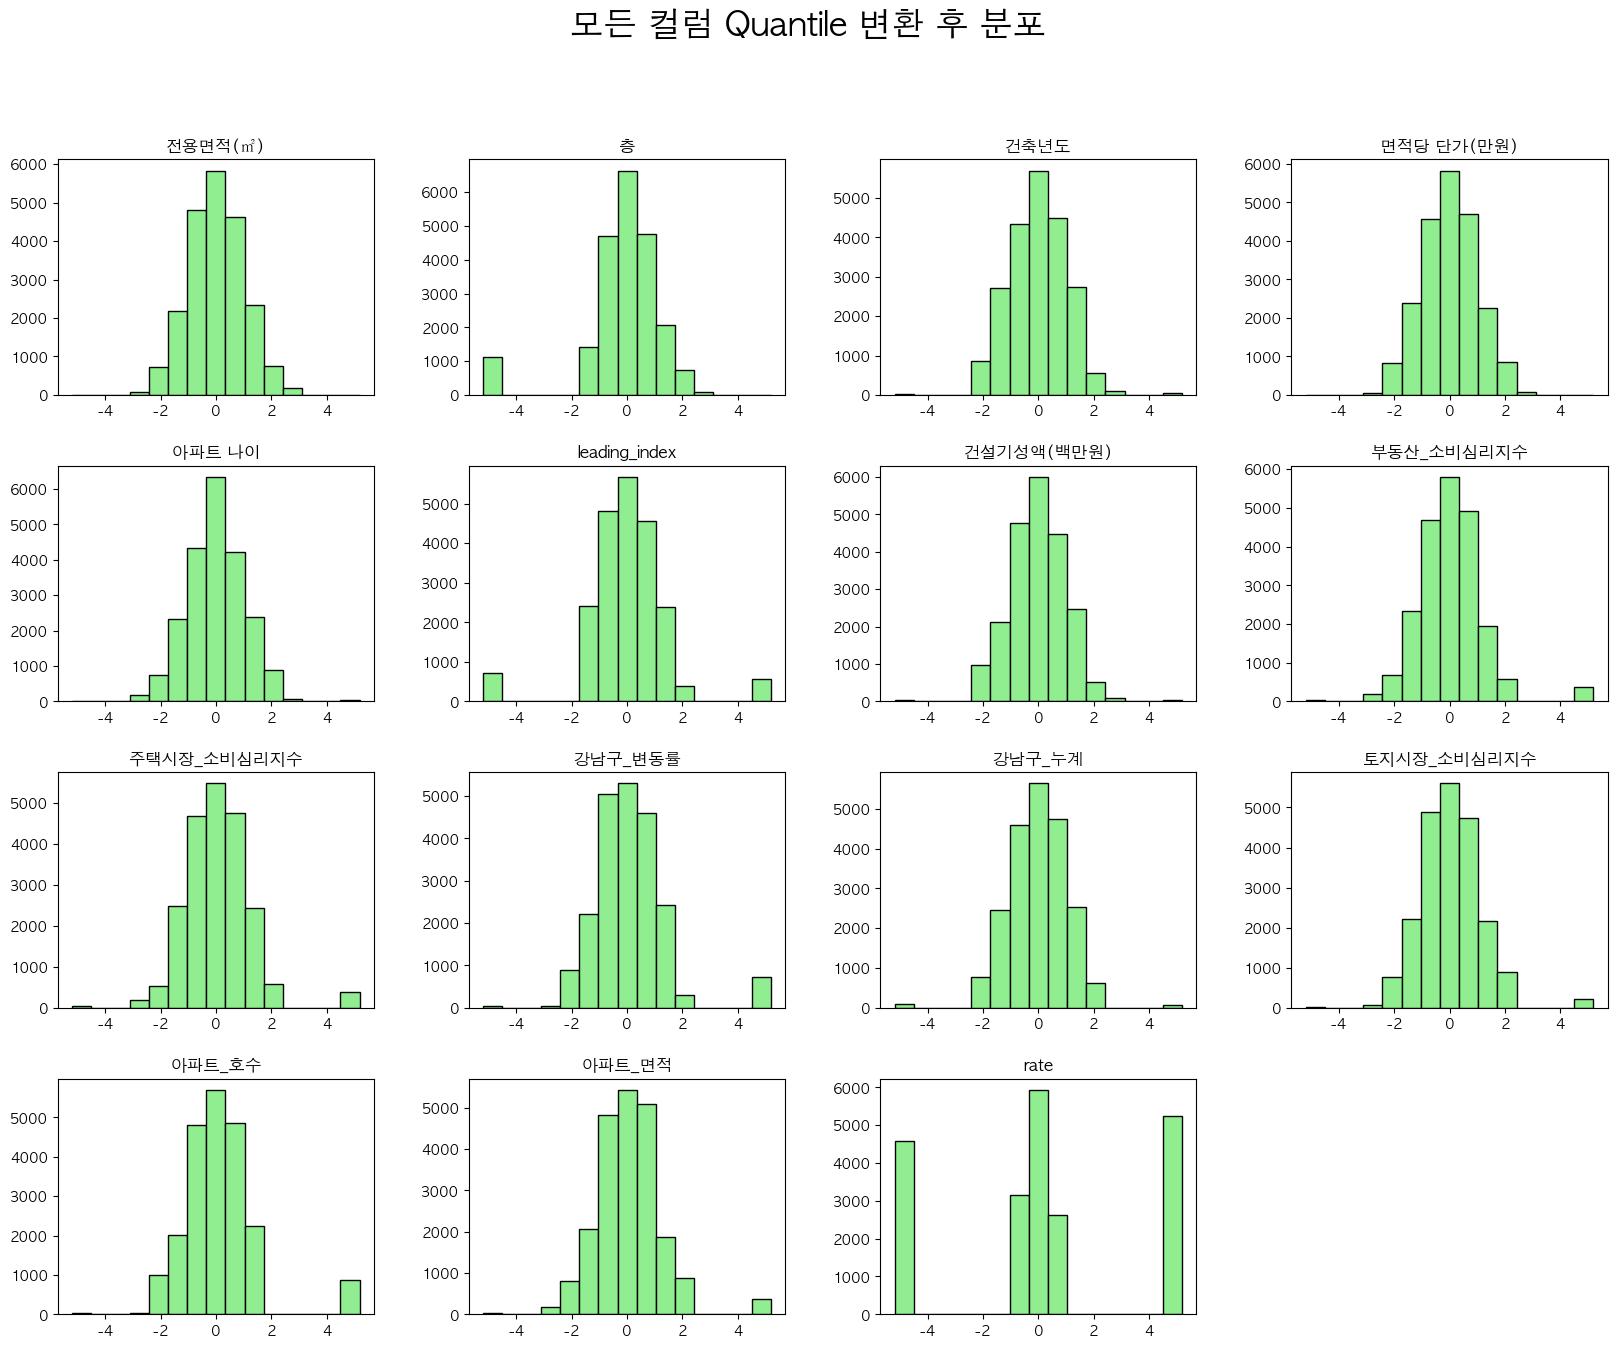

In [203]:
df_only_qt = df.copy()

# 모든 숫자형 컬럼을 QuantileTransformer로 변환
all_numeric_cols = df.select_dtypes(include=np.number).columns

qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
df_only_qt[all_numeric_cols] = qt.fit_transform(df[all_numeric_cols])

#df_only_qt[all_numeric_cols] = standard_scaler.fit_transform(df_only_qt[all_numeric_cols])

# 변환 후 히스토그램 확인
axes_after = df_only_qt[all_numeric_cols].hist(figsize=(20, 15), bins=15, color='lightgreen', edgecolor='black')
plt.suptitle("모든 컬럼 Quantile 변환 후 분포", fontsize=24)
for ax in axes_after.ravel():
    ax.grid(False)

In [204]:
df_only_qt.describe()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
count,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000
mean,0.008467,-0.157181,0.003140,-0.001739,0.009719,2021-12-10 19:21:45.857798912,-0.024967,-0.003154,0.046668,0.046441,0.093527,0.002081,0.027603,0.117688,0.042687,0.134996
min,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,2018-07-01 00:00:00,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338
25%,-0.657663,-0.747859,-0.682458,-0.672322,-0.666564,2019-11-09 00:00:00,-0.666564,-0.682458,-0.682458,-0.682458,-0.698526,-0.682458,-0.666564,-0.714776,-0.619855,-0.666564
50%,0.001948,0.000000,-0.012660,-0.005100,0.025322,2021-05-02 00:00:00,0.012660,-0.012660,-0.012660,-0.012660,0.025322,-0.012660,0.000000,0.037988,0.037988,-0.178175
75%,0.680361,0.747859,0.650837,0.664302,0.650837,2024-05-02 00:00:00,0.682458,0.666564,0.650837,0.698526,0.682458,0.650837,0.635270,0.650837,0.650837,0.650837
max,5.199338,5.199338,5.199338,5.199338,5.199338,2025-06-30 00:00:00,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338
std,0.991311,1.456415,1.016919,0.996151,1.008768,NaN,1.517252,1.037672,1.186932,1.187839,1.326053,1.071242,1.093898,1.383327,1.179830,3.522705


In [205]:
df_boxcox_qt.describe()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
count,21561.000000,21561.000000,2.156100e+04,21561.000000,21561.000000,21561,2.156100e+04,2.156100e+04,2.156100e+04,21561.000000,21561.000000,21561.000000,2.156100e+04,21561.000000,21561.000000,2.156100e+04
mean,0.009714,-0.161077,-7.856472e-16,-0.003894,-0.027728,2021-12-10 19:21:45.857798912,-1.931954e-14,5.006069e-10,-1.476384e-16,0.046888,0.098092,-0.003516,-4.850976e-16,0.107968,0.032407,4.218240e-17
min,-5.199338,-5.199338,-1.953148e+00,-5.199338,-5.199338,2018-07-01 00:00:00,-1.386253e+00,-2.331092e+00,-2.489027e+00,-5.199338,-5.199338,-5.199338,-2.185788e+00,-5.199338,-5.199338,-1.446981e+00
25%,-0.651463,-0.781781,-8.940034e-01,-0.682366,-0.698526,2019-11-09 00:00:00,-9.967790e-01,-7.853589e-01,-7.223361e-01,-0.682458,-0.698526,-0.650837,-8.412971e-01,-0.714776,-0.635270,-7.504746e-01
50%,0.010893,0.000000,1.452190e-01,-0.002330,0.000000,2021-05-02 00:00:00,1.416734e-01,7.259170e-02,5.897736e-02,-0.012660,0.025322,-0.025322,7.796184e-02,0.012660,0.025322,-2.276559e-01
75%,0.672079,0.747859,6.436844e-01,0.671786,0.635270,2024-05-02 00:00:00,1.078474e+00,7.908553e-01,8.425373e-01,0.666564,0.698526,0.635270,8.118316e-01,0.650837,0.650837,1.083982e+00
max,5.199338,5.199338,2.123380e+00,5.199338,5.199338,2025-06-30 00:00:00,1.505621e+00,2.402559e+00,2.223119e+00,5.199338,5.199338,5.199338,2.202526e+00,5.199338,5.199338,1.235893e+00
std,0.991349,1.467218,1.000023e+00,0.990699,1.097151,NaN,1.000023e+00,1.000023e+00,1.000023e+00,1.184875,1.328389,1.060740,1.000023e+00,1.382314,1.178963,1.000023e+00


### Box-cow with QuantileTrans

In [206]:
df_boxcox_qt.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate,date,image_filename,image_path
0,0.037988,-0.544847,-0.421191,-0.804627,0.13971,2018-07-01,-1.371989,-0.734744,-0.564293,-0.486994,1.549706,0.191052,-0.30333,-1.194396,-0.987837,-0.227656,2018-07,apt_image_0.jpg,../../data/interim/satellites/gang_nam_rot_90/...


In [207]:
# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df_boxcox_qt.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename', 'date'])
y_target = df_boxcox_qt[TARGET_COLUMN]

In [208]:
X_tabular.head(1)

,전용면적(㎡),층,건축년도,아파트 나이,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
0,0.037988,-0.544847,-0.421191,0.13971,-1.371989,-0.734744,-0.564293,-0.486994,1.549706,0.191052,-0.30333,-1.194396,-0.987837,-0.227656


In [209]:
y_target.head(1)

0   -0.804627
Name: 면적당 단가(만원), dtype: float64

In [210]:
# --- 3. 다중 모달 특징 추출 ---

# 3-1. 특징 추출기 모델 정의 (수정 없음, Input 레이어의 name이 중요해짐)
print("3. 특징 추출기 모델을 정의합니다...")
def create_feature_extractor_model(num_tabular_features, image_shape=(224, 224, 3)):
    # --- 입력층 정의 ---
    # 1. 인구통계, 주택 관련, KDE 특징을 포함하는 정형 데이터 입력
    tabular_input = Input(shape=(num_tabular_features,), name='tabular_input')
    # 2. 이미지 데이터 입력
    image_input = Input(shape=image_shape, name='image_input')
    
    
    # --- 특징별 처리 스트림 ---
    
    # 이미지 특징 처리 부분 (3개의 은닉층) 
    base_cnn = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    base_cnn.trainable = False
    x_image = GlobalAveragePooling2D()(base_cnn.output)
    x_image = Dense(128, activation='relu')(x_image)
    # 정형 모델과 출력층을 맞춰서 큰 특징에 의존하지 않도록 64로 출력하도록 설정함 (9.19)
    image_features = Dense(64, activation='relu')(x_image)
    #image_features = Dense(32, activation='relu')(x_image)

    # 정형 데이터(인구통계, 주택, KDE) 처리 부분 (1개의 은닉층) 
    tabular_features = Dense(64, activation='relu')(tabular_input)

    
    # --- 특징 결합 및 최종 예측 ---
    
    # 두 부분의 출력을 결합 
    combined = Concatenate()([image_features, tabular_features])
    normalized_featurees = BatchNormalization()(combined)
    
    # 결합된 특징을 256개 뉴런을 가진 은닉층으로 처리 
    x = Dense(256, activation='relu')(normalized_featurees)
    
    # 최종 가격을 예측하는 출력 뉴런 
    # 벡터형태로 LSTM에 넘겨야해서 주석처리 ㄱㄱ
    # prediction = Dense(1, activation='linear', name='price_output')(x)
    
    # --- 모델 생성 ---
    model = Model(inputs=[tabular_input, image_input], outputs=x, name='apartment_predictor')
    
    return model

# 3-2. 특징 추출을 위한 데이터 제너레이터 (수정됨)
def prediction_generator(tabular_data, image_paths, batch_size, image_shape=(224,224,3)):
    num_samples = len(tabular_data)
    for offset in range(0, num_samples, batch_size):
        batch_tabular = tabular_data.iloc[offset:offset+batch_size].values.astype(np.float32)
        batch_paths = image_paths.iloc[offset:offset+batch_size]
        
        batch_images = []
        for path in batch_paths:
            try:
                img = load_img(path, target_size=image_shape[:2])
                img_array = img_to_array(img) / 255.0
                batch_images.append(img_array)
            except FileNotFoundError:
                batch_images.append(np.zeros(image_shape, dtype=np.float32))
        
        yield {
            'tabular_input': np.array(batch_tabular, dtype=np.float32),
            'image_input': np.array(batch_images, dtype=np.float32)
        }




# 3-3. 전체 데이터에 대한 특징 추출 실행 
print("4. 전체 데이터에 대한 특징을 추출합니다...")
feature_extractor = create_feature_extractor_model(num_tabular_features=X_tabular.shape[1])

# 출력 형식을 딕셔너리 구조로 명시
output_signature = {
    'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
    'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
}

# from_generator를 사용하여 데이터셋 생성
pred_dataset = tf.data.Dataset.from_generator(
    # 수정: 올바른 DataFrame 'X_tabular' 사용
    lambda: prediction_generator(X_tabular, df['image_path'], BATCH_SIZE),
    output_signature={
        # 수정: 형태(shape)를 가져오기 위해 올바른 DataFrame 'X_tabular' 사용
        'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
        'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
    }
)


# predict 함수에 tf.data.Dataset을 직접 전달
all_features = feature_extractor.predict(pred_dataset, verbose=1)

print("\n🎉 특징 추출이 성공적으로 완료되었습니다!")
print("추출된 특징의 모양:", all_features.shape)

3. 특징 추출기 모델을 정의합니다...
4. 전체 데이터에 대한 특징을 추출합니다...


2025-09-19 21:48:32.982940: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


337/337 [==============================] - 469s 1s/step

🎉 특징 추출이 성공적으로 완료되었습니다!
추출된 특징의 모양: (21561, 256)


In [211]:
# --- 4. 시퀀스 데이터 생성 ---

print("\n5. 시계열 데이터를 생성합니다...")
def create_sequences(X_data, y_data, lookback):
    X_sequences, y_sequences = [], []
    # 데이터 길이에서 lookback 길이를 뺀 만큼 반복
    for i in range(len(X_data) - lookback):
        # i부터 i+lookback까지의 데이터를 하나의 시퀀스로
        X_sequences.append(X_data[i:(i + lookback)])
        # 시퀀스 바로 다음의 데이터를 정답으로
        y_sequences.append(y_data[i + lookback])
    return np.array(X_sequences), np.array(y_sequences)

# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(all_features, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]



5. 시계열 데이터를 생성합니다...
생성된 시퀀스 데이터 모양 (X): (21551, 10, 256)
생성된 시퀀스 데이터 모양 (y): (21551,)


In [212]:
def create_lstm_model(input_shape):
    input_layer = Input(shape=input_shape)
    x = LSTM(128, activation='relu', return_sequences=True)(input_layer)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)  
    prediction = Dense(1, activation='linear')(x)

    model = Model(inputs=input_layer, outputs=prediction, name='lstm_forecaster')
    return model

In [213]:
def create_future_sequences(all_features, original_df, lookback=10, horizon_days=30):
    """
    특정 기간(horizon_days) 후의 가격을 예측하기 위한 시계열 데이터를 생성합니다.
    
    :param all_features: (샘플 수, 특징 수) 모양의 전체 특징 데이터
    :param original_df: 날짜와 타겟 컬럼이 포함된 원본 데이터프레임
    :param lookback: 과거를 돌아볼 기간 (시퀀스 길이)
    :param horizon_days: 예측할 미래 기간 (일 단위)
    :return: X_sequences (입력 시퀀스), y_sequences (미래 시점의 정답)
    """
    X_sequences, y_sequences = [], []
    
    # 날짜와 타겟 값을 쉽게 조회할 수 있도록 Series로 변환
    dates = original_df['계약일자']
    targets = original_df[TARGET_COLUMN].values
    
    for i in range(len(all_features) - lookback):
        # 입력 시퀀스의 마지막 날짜
        end_of_input_sequence_date = dates[i + lookback - 1]
        
        # 예측 목표 날짜 설정
        target_date = end_of_input_sequence_date + pd.Timedelta(days=horizon_days)
        
        # 목표 날짜 이후의 데이터만 필터링
        future_data_indices = np.where(dates >= target_date)[0]
        
        # 목표 날짜 이후에 거래가 있다면
        if len(future_data_indices) > 0:
            # 가장 가까운 미래 거래의 인덱스를 찾음
            future_target_index = future_data_indices[0]
            
            # 해당 인덱스가 전체 특징 데이터 길이를 벗어나지 않는지 확인
            if future_target_index < len(all_features):
                # 입력 시퀀스 생성
                X_sequences.append(all_features[i:(i + lookback)])
                # 미래 시점의 가격을 정답으로 지정
                y_sequences.append(targets[future_target_index])
                
    return np.array(X_sequences), np.array(y_sequences)

In [214]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 20980
3개월 후 예측용 데이터 샘플 수: 20719
6개월 후 예측용 데이터 샘플 수: 18906


In [215]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_6m = lstm_model_6m.fit(
    X_train_6m, y_train_6m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_6m, y_test_6m),
    callbacks=[early_stopping],
    verbose=1
)


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100
263/263 [==============================] - 4s 11ms/step - loss: 55.3470 - mae: 7.4264 - val_loss: 57.2186 - val_mae: 7.5466
Epoch 2/100
263/263 [==============================] - 3s 12ms/step - loss: 39.5255 - mae: 6.0037 - val_loss: 36.5031 - val_mae: 5.5345
Epoch 3/100
263/263 [==============================] - 3s 11ms/step - loss: 26.8942 - mae: 4.5644 - val_loss: 23.9549 - val_mae: 3.9872
Epoch 4/100
263/263 [==============================] - 3s 11ms/step - loss: 17.6673 - mae: 3.2482 - val_loss: 16.4560 - val_mae: 2.9665
Epoch 5/100
263/263 [==============================] - 3s 12ms/step - loss: 13.3367 - mae: 2.6145 - val_loss: 13.0034 - val_mae: 2.5056
Epoch 6/100
263/263 [==============================] - 3s 12ms/step - loss: 10.7666 - mae: 2.2241 - val_loss: 10.6357 - val_mae: 2.1610
Epoch 7/100
263/263 [==============================] - 3s 12ms/step - loss: 8.8741 - mae: 1.9318 - val_loss: 8.8442 - val_mae: 1.9096
Epoch 8/100
263/263 [==


--- 3개월 후 예측 모델 학습 시작 ---
Epoch 1/100
259/259 [==============================] - 3s 11ms/step - loss: 54.0998 - mae: 7.3388 - val_loss: 53.4104 - val_mae: 7.2789
Epoch 2/100
259/259 [==============================] - 3s 11ms/step - loss: 35.3694 - mae: 5.5804 - val_loss: 31.6655 - val_mae: 5.0423
Epoch 3/100
259/259 [==============================] - 3s 12ms/step - loss: 22.2563 - mae: 3.9521 - val_loss: 18.6933 - val_mae: 3.3252
Epoch 4/100
259/259 [==============================] - 3s 13ms/step - loss: 15.3095 - mae: 2.9481 - val_loss: 14.1678 - val_mae: 2.7089
Epoch 5/100
259/259 [==============================] - 3s 11ms/step - loss: 12.1674 - mae: 2.4860 - val_loss: 11.6152 - val_mae: 2.3727
Epoch 6/100
259/259 [==============================] - 3s 11ms/step - loss: 10.0460 - mae: 2.1630 - val_loss: 9.6811 - val_mae: 2.0989
Epoch 7/100
259/259 [==============================] - 3s 11ms/step - loss: 8.4092 - mae: 1.9057 - val_loss: 8.1119 - val_mae: 1.8499
Epoch 8/100
259/259 [===


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
237/237 [==============================] - 3s 11ms/step - loss: 56.7999 - mae: 7.5247 - val_loss: 60.2805 - val_mae: 7.7540
Epoch 2/100
237/237 [==============================] - 3s 11ms/step - loss: 45.1758 - mae: 6.5611 - val_loss: 36.9759 - val_mae: 5.6712
Epoch 3/100
237/237 [==============================] - 3s 11ms/step - loss: 29.5942 - mae: 4.8832 - val_loss: 27.5775 - val_mae: 4.4813
Epoch 4/100
237/237 [==============================] - 3s 11ms/step - loss: 20.1028 - mae: 3.5925 - val_loss: 19.5680 - val_mae: 3.3815
Epoch 5/100
237/237 [==============================] - 3s 11ms/step - loss: 15.5731 - mae: 2.9480 - val_loss: 16.1288 - val_mae: 2.9482
Epoch 6/100
237/237 [==============================] - 2s 11ms/step - loss: 13.0398 - mae: 2.5829 - val_loss: 13.8174 - val_mae: 2.6659
Epoch 7/100
237/237 [==============================] - 3s 11ms/step - loss: 11.0786 - mae: 2.2895 - val_loss: 11.8965 - val_mae: 2.4262
Epoch 8/100
237/237 [

In [216]:
import matplotlib.pyplot as plt
import pandas as pd # pd.Series를 위해 import
import numpy as np # np.expm1을 위해 import
from sklearn.metrics import mean_absolute_error

# --- 분석 및 시각화 함수 수정 ---
def analyze_and_visualize_model(model, X_test_seq, y_test_seq, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_seq)

    # ❗️ [수정] y_pred_log의 차원 확인 및 조정
    if y_pred_log.ndim >= 2:
        y_pred_log = y_pred_log.flatten()

    # 2. 역변환 (로그 -> 원본 단위)
    y_pred_original = np.expm1(y_pred_log)

    # ❗️ [수정] y_test_seq도 동일하게 차원 조정 및 역변환
    y_test_original = np.expm1(y_test_seq)
    
    if y_test_original.ndim >= 2:
        y_test_original = y_test_original.flatten()
        
    # ❗️ [수정] 두 배열의 길이를 동일하게 맞춰줍니다.
    #    예측값의 길이를 기준으로 실제값의 길이를 자릅니다.
    min_len = min(len(y_test_original), len(y_pred_original))
    y_test_np = y_test_original[:min_len]
    y_pred_original = y_pred_original[:min_len]


    # 3. 원본 단위(만원)로 MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(min(5, len(y_test_np))):
        print(f"실제 단가: {y_test_np[i]:.2f} (만원)  |  예측 단가: {y_pred_original[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    print(f"Real World MAE: {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    
    min_val = min(y_test_np.min(), y_pred_original.min())
    max_val = max(y_test_np.max(), y_pred_original.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


--- 1개월 후 예측 모델 성능 분석 시작 ---
132/132 [==============================] - 0s 2ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1385.35 (만원)  |  예측 단가: 5265.18 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2282.33 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2083.34 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2012.06 (만원)
실제 단가: 3639.78 (만원)  |  예측 단가: 1995.99 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1471.56 (만원)


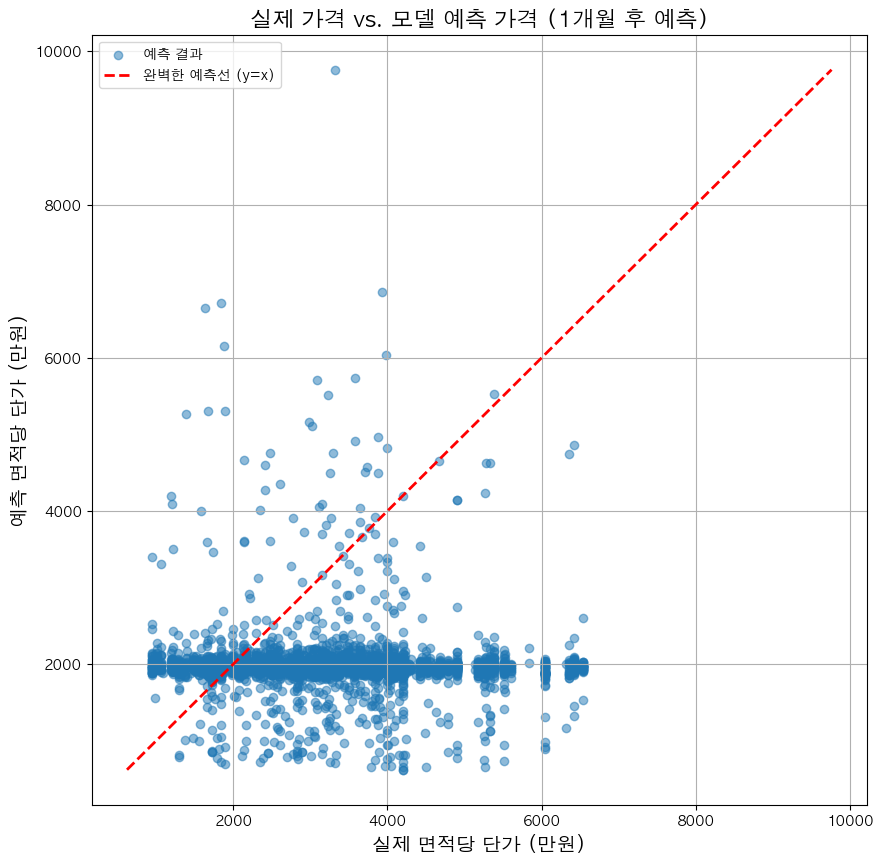


--- 3개월 후 예측 모델 성능 분석 시작 ---
130/130 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1206.20 (만원)  |  예측 단가: 1838.78 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1914.35 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1983.58 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2004.04 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1996.21 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1296.36 (만원)


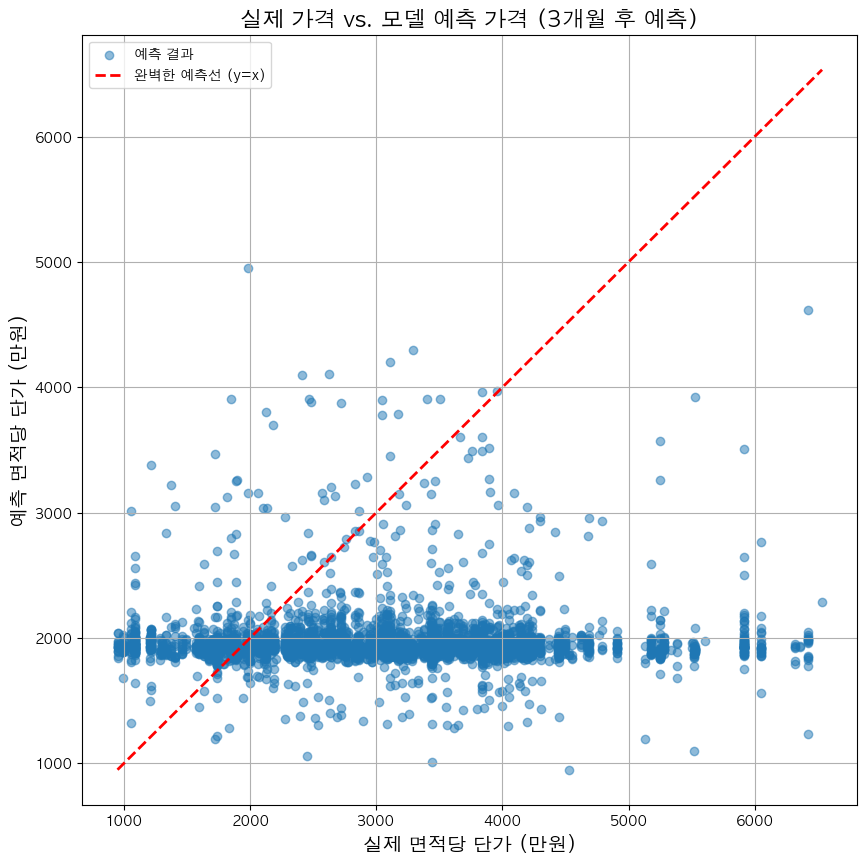


--- 6개월 후 예측 모델 성능 분석 시작 ---
119/119 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 2605.93 (만원)  |  예측 단가: 1831.91 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1827.43 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1758.79 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1775.59 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1786.19 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1443.62 (만원)


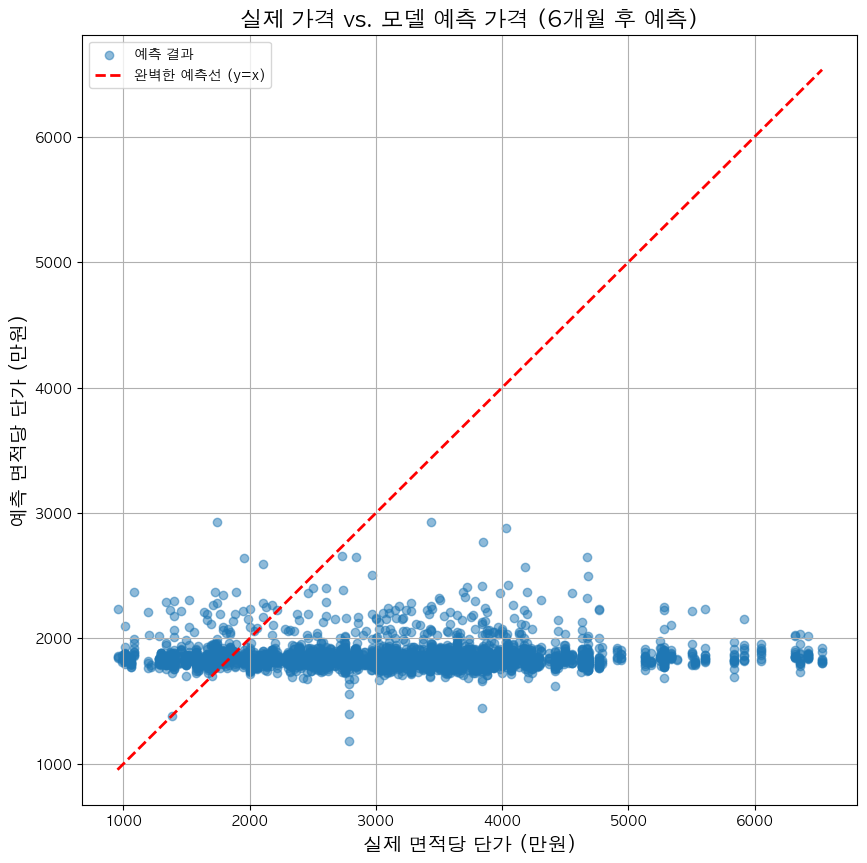

In [217]:

# --- 함수 실행 (기존 코드와 동일) ---
# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석 (만약 모델이 있다면)
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")


### Only Quantile

In [218]:
df_only_qt.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate,date,image_filename,image_path
0,0.01421,-0.515705,-0.308666,-0.797101,0.165327,2018-07-01,-1.639976,-0.544847,-0.486994,-0.486994,1.508944,0.203961,-0.203961,-1.194396,-0.967422,-0.178175,2018-07,apt_image_0.jpg,../../data/interim/satellites/gang_nam_rot_90/...


In [219]:
# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df_only_qt.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename', 'date'])
y_target = df_only_qt[TARGET_COLUMN]

In [220]:

# 3-3. 전체 데이터에 대한 특징 추출 실행 
print("4. 전체 데이터에 대한 특징을 추출합니다...")
feature_extractor = create_feature_extractor_model(num_tabular_features=X_tabular.shape[1])

# 출력 형식을 딕셔너리 구조로 명시
output_signature = {
    'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
    'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
}

# from_generator를 사용하여 데이터셋 생성
pred_dataset = tf.data.Dataset.from_generator(
    # 수정: 올바른 DataFrame 'X_tabular' 사용
    lambda: prediction_generator(X_tabular, df['image_path'], BATCH_SIZE),
    output_signature={
        # 수정: 형태(shape)를 가져오기 위해 올바른 DataFrame 'X_tabular' 사용
        'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
        'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
    }
)


# predict 함수에 tf.data.Dataset을 직접 전달
all_features = feature_extractor.predict(pred_dataset, verbose=1)

print("\n🎉 특징 추출이 성공적으로 완료되었습니다!")
print("추출된 특징의 모양:", all_features.shape)

4. 전체 데이터에 대한 특징을 추출합니다...


2025-09-19 22:06:23.739403: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


337/337 [==============================] - 458s 1s/step

🎉 특징 추출이 성공적으로 완료되었습니다!
추출된 특징의 모양: (21561, 256)


In [221]:
# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(all_features, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]

생성된 시퀀스 데이터 모양 (X): (21551, 10, 256)
생성된 시퀀스 데이터 모양 (y): (21551,)


In [222]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 20980
3개월 후 예측용 데이터 샘플 수: 20719
6개월 후 예측용 데이터 샘플 수: 18906


In [223]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]

In [224]:
# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_6m = lstm_model_6m.fit(
    X_train_6m, y_train_6m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_6m, y_test_6m),
    callbacks=[early_stopping],
    verbose=1
)


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100
263/263 [==============================] - 3s 10ms/step - loss: 52.9427 - mae: 7.2499 - val_loss: 51.3439 - val_mae: 7.1263
Epoch 2/100
263/263 [==============================] - 3s 10ms/step - loss: 30.3517 - mae: 5.0299 - val_loss: 26.6972 - val_mae: 4.4539
Epoch 3/100
263/263 [==============================] - 3s 10ms/step - loss: 18.1579 - mae: 3.3737 - val_loss: 16.5544 - val_mae: 2.9396
Epoch 4/100
263/263 [==============================] - 3s 10ms/step - loss: 12.5580 - mae: 2.5374 - val_loss: 12.4262 - val_mae: 2.3646
Epoch 5/100
263/263 [==============================] - 3s 10ms/step - loss: 9.6748 - mae: 2.0902 - val_loss: 9.9490 - val_mae: 2.0462
Epoch 6/100
263/263 [==============================] - 3s 10ms/step - loss: 7.7487 - mae: 1.7856 - val_loss: 8.2914 - val_mae: 1.8722
Epoch 7/100
263/263 [==============================] - 3s 10ms/step - loss: 6.3313 - mae: 1.5627 - val_loss: 6.8638 - val_mae: 1.6529
Epoch 8/100
263/263 [======


--- 3개월 후 예측 모델 학습 시작 ---
Epoch 1/100
259/259 [==============================] - 3s 10ms/step - loss: 52.1756 - mae: 7.1928 - val_loss: 47.2189 - val_mae: 6.7996
Epoch 2/100
259/259 [==============================] - 3s 10ms/step - loss: 29.7671 - mae: 4.9627 - val_loss: 26.4478 - val_mae: 4.4615
Epoch 3/100
259/259 [==============================] - 3s 10ms/step - loss: 18.8721 - mae: 3.4690 - val_loss: 16.7757 - val_mae: 3.0222
Epoch 4/100
259/259 [==============================] - 3s 10ms/step - loss: 12.9909 - mae: 2.5879 - val_loss: 12.6420 - val_mae: 2.4603
Epoch 5/100
259/259 [==============================] - 3s 10ms/step - loss: 10.0060 - mae: 2.1355 - val_loss: 10.0610 - val_mae: 2.1057
Epoch 6/100
259/259 [==============================] - 3s 10ms/step - loss: 8.0018 - mae: 1.8165 - val_loss: 8.2298 - val_mae: 1.8399
Epoch 7/100
259/259 [==============================] - 3s 10ms/step - loss: 6.5385 - mae: 1.5813 - val_loss: 6.8816 - val_mae: 1.6674
Epoch 8/100
259/259 [====


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
237/237 [==============================] - 3s 10ms/step - loss: 54.0584 - mae: 7.3313 - val_loss: 53.6723 - val_mae: 7.2997
Epoch 2/100
237/237 [==============================] - 2s 10ms/step - loss: 32.2833 - mae: 5.2484 - val_loss: 28.7531 - val_mae: 4.6968
Epoch 3/100
237/237 [==============================] - 2s 10ms/step - loss: 20.6562 - mae: 3.7155 - val_loss: 18.9567 - val_mae: 3.2425
Epoch 4/100
237/237 [==============================] - 2s 10ms/step - loss: 14.3529 - mae: 2.7770 - val_loss: 14.4330 - val_mae: 2.6873
Epoch 5/100
237/237 [==============================] - 2s 10ms/step - loss: 11.2797 - mae: 2.3134 - val_loss: 11.6500 - val_mae: 2.3254
Epoch 6/100
237/237 [==============================] - 2s 11ms/step - loss: 9.1511 - mae: 1.9730 - val_loss: 9.6030 - val_mae: 2.0477
Epoch 7/100
237/237 [==============================] - 2s 10ms/step - loss: 7.5684 - mae: 1.7239 - val_loss: 7.9959 - val_mae: 1.7946
Epoch 8/100
237/237 [====


--- 1개월 후 예측 모델 성능 분석 시작 ---
132/132 [==============================] - 0s 2ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1385.35 (만원)  |  예측 단가: 2556.74 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 1921.65 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 1753.96 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 1715.69 (만원)
실제 단가: 3639.78 (만원)  |  예측 단가: 1777.42 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1581.46 (만원)


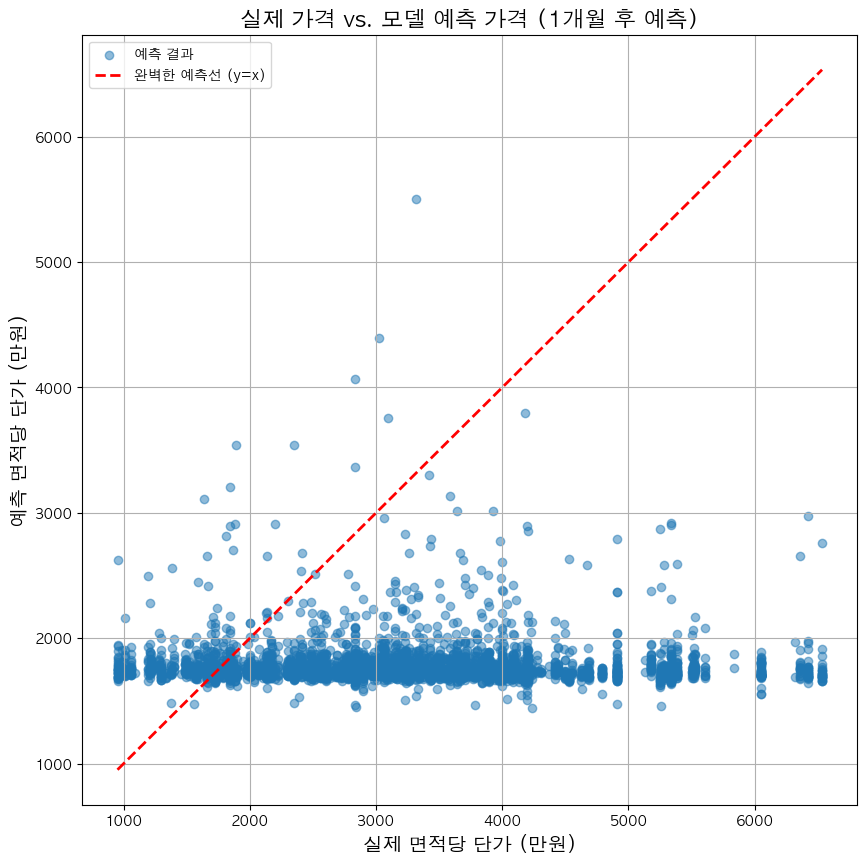


--- 3개월 후 예측 모델 성능 분석 시작 ---
130/130 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1206.20 (만원)  |  예측 단가: 1963.01 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1785.31 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1671.08 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1741.25 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1805.98 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1374.10 (만원)


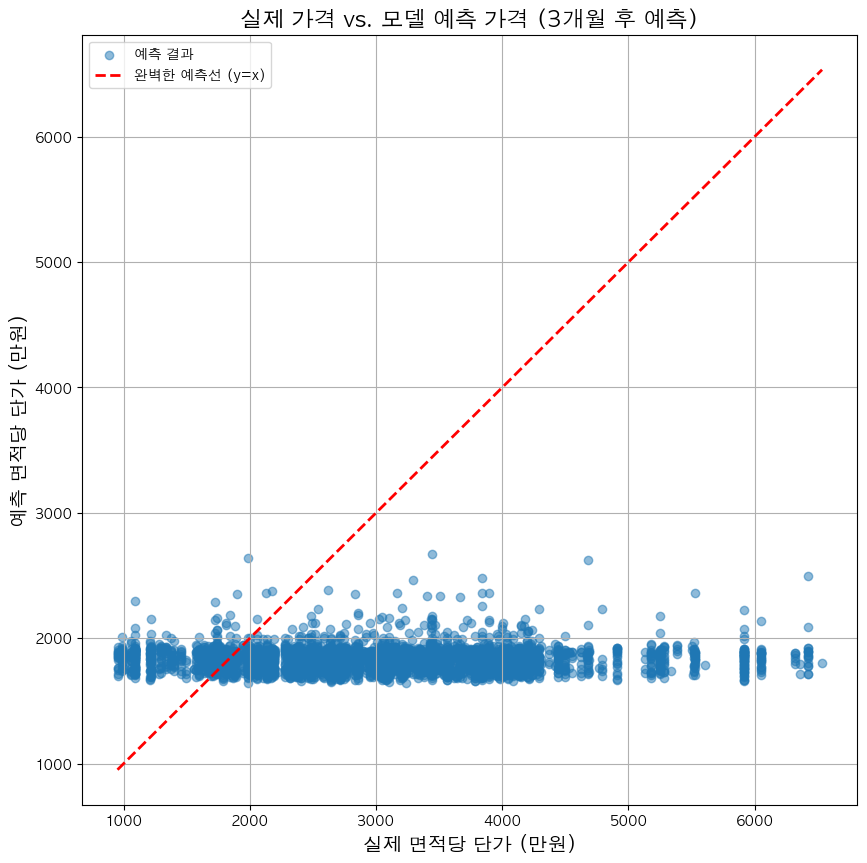


--- 6개월 후 예측 모델 성능 분석 시작 ---
119/119 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 2605.93 (만원)  |  예측 단가: 2340.83 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1881.28 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1766.68 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1735.99 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 1675.37 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1474.23 (만원)


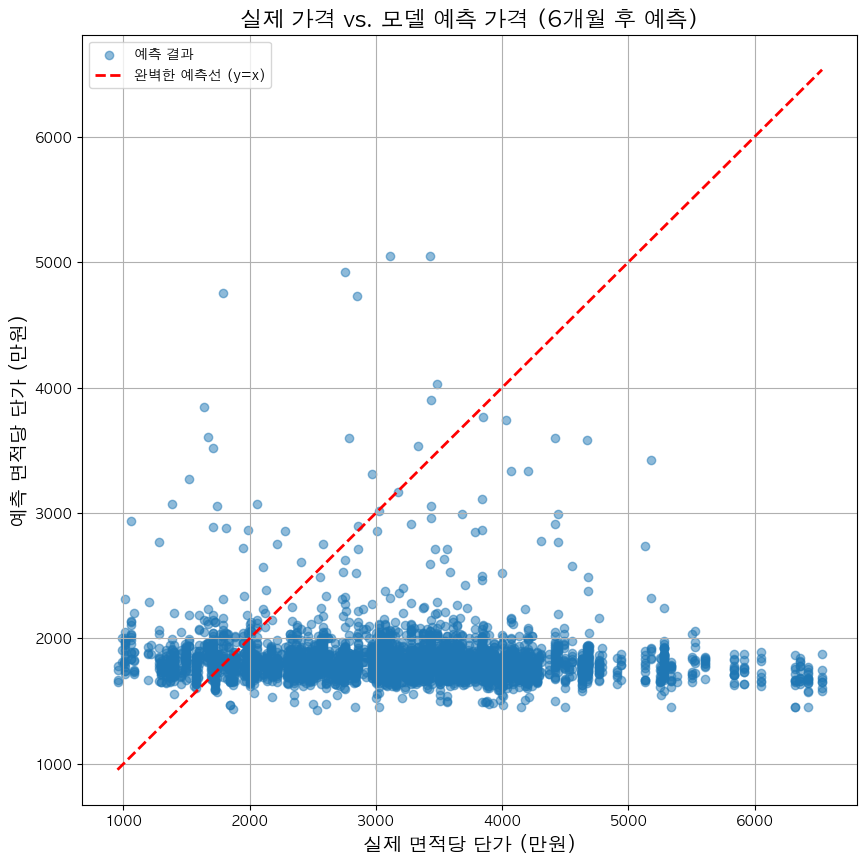

In [225]:

# --- 함수 실행 (기존 코드와 동일) ---
# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석 (만약 모델이 있다면)
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")
